# Fake News Detection — Baseline Models

**CST-3121 Group Project** | ML Model Development Lead deliverable

Train and compare **Logistic Regression** and **Random Forest** classifiers using TF-IDF features.

## 1. Setup

In [ ]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)

PROJECT_ROOT = Path("..").resolve()

OUTPUT_DIR = PROJECT_ROOT / "Output"

FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load Train / Val / Test Splits

In [3]:
train_df = pd.read_csv(OUTPUT_DIR / "train.csv")
val_df = pd.read_csv(OUTPUT_DIR / "val.csv")
test_df = pd.read_csv(OUTPUT_DIR / "test.csv")

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

X_train = train_df["full_text"]
y_train = train_df["label_num"]

X_val = val_df["full_text"]
y_val = val_df["label_num"]

X_test = test_df["full_text"]
y_test = test_df["label_num"]

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

(4386, 9)
(940, 9)
(941, 9)
Train: 4386 | Val: 940 | Test: 941


## 3. TF-IDF Feature Engineering

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    stop_words="english",
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")

TF-IDF matrix shape (train): (4386, 10000)


## 4. Helper Functions

In [5]:
def evaluate_model(name, model, X, y):
    y_pred = model.predict(X)
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred),
        "recall": recall_score(y, y_pred),
        "f1": f1_score(y, y_pred),
    }
    return metrics, y_pred


def plot_confusion_matrix(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots()
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["REAL", "FAKE"],
        yticklabels=["REAL", "FAKE"],
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

## 5. Baseline 1 — Logistic Regression

Best LR params: {'C': 10.0}
Best CV F1: 0.9323
{'model': 'Logistic Regression', 'accuracy': 0.926595744680851, 'precision': 0.919831223628692, 'recall': 0.9336188436830836, 'f1': 0.926673751328374}


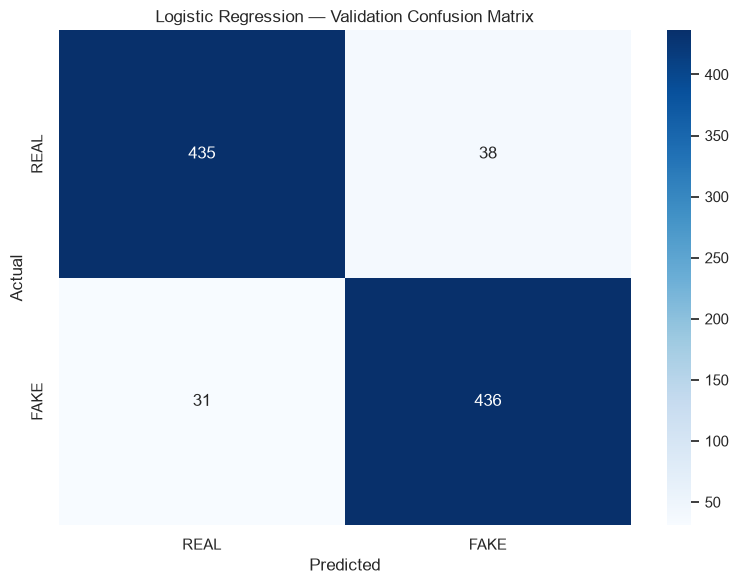

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    param_grid={"C": [0.1, 1.0, 10.0]},
    cv=cv,
    scoring="f1",
    n_jobs=-1,
)

lr_grid.fit(X_train_tfidf, y_train)
lr_model = lr_grid.best_estimator_

print("Best LR params:", lr_grid.best_params_)
print(f"Best CV F1: {lr_grid.best_score_:.4f}")

lr_val_metrics, lr_val_pred = evaluate_model("Logistic Regression", lr_model, X_val_tfidf, y_val)
print(lr_val_metrics)

plot_confusion_matrix(
    y_val,
    lr_val_pred,
    "Logistic Regression — Validation Confusion Matrix",
    FIGURES_DIR / "lr_confusion_matrix.png",
)

## 6. Baseline 2 — Random Forest

Best RF params: {'max_depth': None, 'n_estimators': 200}
Best CV F1: 0.9046
{'model': 'Random Forest', 'accuracy': 0.9234042553191489, 'precision': 0.9265658747300216, 'recall': 0.9186295503211992, 'f1': 0.9225806451612903}


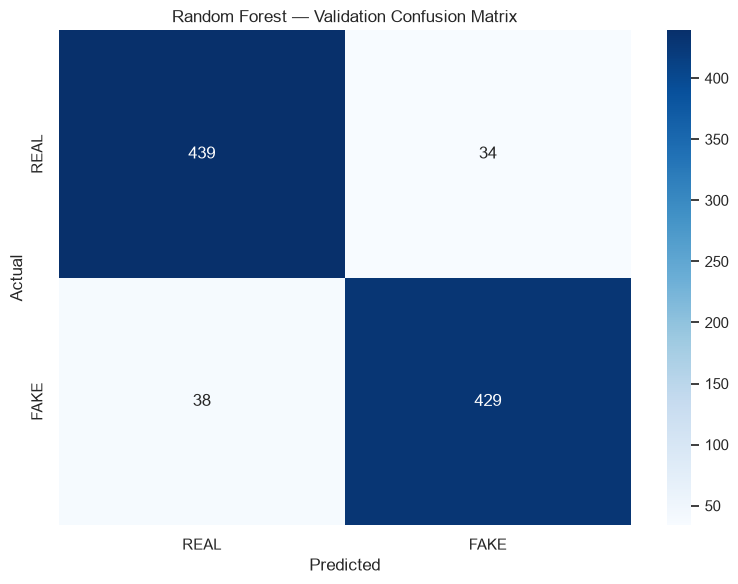

In [7]:
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_grid={
        "n_estimators": [100, 200],
        "max_depth": [None, 20, 40],
    },
    cv=cv,
    scoring="f1",
    n_jobs=-1,
)

rf_grid.fit(X_train_tfidf, y_train)
rf_model = rf_grid.best_estimator_

print("Best RF params:", rf_grid.best_params_)
print(f"Best CV F1: {rf_grid.best_score_:.4f}")

rf_val_metrics, rf_val_pred = evaluate_model("Random Forest", rf_model, X_val_tfidf, y_val)
print(rf_val_metrics)

plot_confusion_matrix(
    y_val,
    rf_val_pred,
    "Random Forest — Validation Confusion Matrix",
    FIGURES_DIR / "rf_confusion_matrix.png",
)

## 7. Model Comparison (Validation Set)

                     accuracy  precision  recall      f1
model                                                   
Logistic Regression    0.9266     0.9198  0.9336  0.9267
Random Forest          0.9234     0.9266  0.9186  0.9226


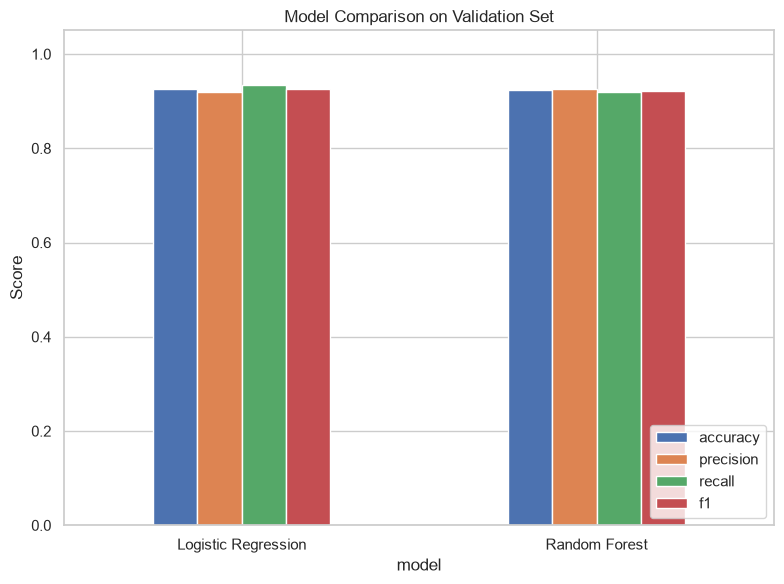

In [8]:
comparison_df = pd.DataFrame([lr_val_metrics, rf_val_metrics])
comparison_df = comparison_df.set_index("model")
print(comparison_df.round(4))

fig, ax = plt.subplots()
metrics_to_plot = ["accuracy", "precision", "recall", "f1"]
comparison_df[metrics_to_plot].plot(kind="bar", ax=ax)
ax.set_title("Model Comparison on Validation Set")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison.png", dpi=150)
plt.show()

## 8. Cross-Validation (5-Fold Stratified)

In [9]:
scoring = ["accuracy", "f1"]

for name, model in [("Logistic Regression", lr_model), ("Random Forest", rf_model)]:
    cv_results = cross_validate(
        model,
        X_train_tfidf,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )
    print(f"\n{name} — 5-fold CV on training set:")
    for metric in scoring:
        scores = cv_results[f"test_{metric}"]
        print(f"  {metric:10s}: {scores.mean():.4f} ± {scores.std():.4f}")


Logistic Regression — 5-fold CV on training set:
  accuracy  : 0.9318 ± 0.0054
  f1        : 0.9323 ± 0.0057

Random Forest — 5-fold CV on training set:
  accuracy  : 0.9056 ± 0.0062
  f1        : 0.9046 ± 0.0068


## 9. Final Test Evaluation

Best model on validation set: Logistic Regression

Test set metrics:
  accuracy: 0.9320
  precision: 0.9189
  recall: 0.9465
  f1: 0.9325

Classification Report (Test Set):
              precision    recall  f1-score   support

        REAL       0.95      0.92      0.93       474
        FAKE       0.92      0.95      0.93       467

    accuracy                           0.93       941
   macro avg       0.93      0.93      0.93       941
weighted avg       0.93      0.93      0.93       941



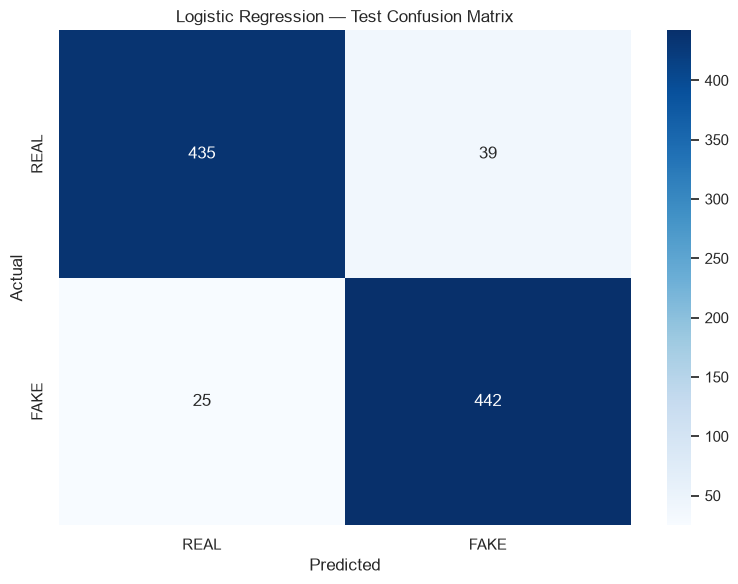

In [10]:
best_model_name = comparison_df["f1"].idxmax()
best_model = lr_model if best_model_name == "Logistic Regression" else rf_model
best_X_test = X_test_tfidf

print(f"Best model on validation set: {best_model_name}")

test_metrics, test_pred = evaluate_model(best_model_name, best_model, best_X_test, y_test)
print("\nTest set metrics:")
for k, v in test_metrics.items():
    if k != "model":
        print(f"  {k}: {v:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, test_pred, target_names=["REAL", "FAKE"]))

plot_confusion_matrix(
    y_test,
    test_pred,
    f"{best_model_name} — Test Confusion Matrix",
    FIGURES_DIR / "best_model_test_confusion_matrix.png",
)

## 10. Error Analysis

In [13]:
error_df = test_df.copy()
error_df["predicted"] = test_pred
error_df["predicted_label"] = error_df["predicted"].map({0: "REAL", 1: "FAKE"})

false_positives = error_df[(error_df["label_num"] == 0) & (error_df["predicted"] == 1)]
false_negatives = error_df[(error_df["label_num"] == 1) & (error_df["predicted"] == 0)]

print(f"False Positives (REAL predicted as FAKE): {len(false_positives)}")
print(f"False Negatives (FAKE predicted as REAL): {len(false_negatives)}")

print("\n--- Sample False Positives ---")
for _, row in false_positives.head(5).iterrows():
    print(f"Title: {row['title_clean'][:80]}")
    print(f"Actual: {row['label']} | Predicted: {row['predicted_label']}")
    print(f"Snippet: {row['full_text'][:150]}...\n")

print("--- Sample False Negatives ---")
for _, row in false_negatives.head(5).iterrows():
    print(f"Title: {row['title_clean'][:80]}")
    print(f"Actual: {row['label']} | Predicted: {row['predicted_label']}")
    print(f"Snippet: {row['full_text'][:150]}...\n")

False Positives (REAL predicted as FAKE): 39
False Negatives (FAKE predicted as REAL): 25

--- Sample False Positives ---
Title: Poroshenko sworn in as Ukraine's president
Actual: REAL | Predicted: FAKE
Snippet: Poroshenko sworn in as Ukraine's president KIEV, Ukraine (AP) — Petro Poroshenko took the oath of office as Ukraine's president Saturday, calling on a...

Title: This is why they hate us: The real American history neither Ted Cruz nor the New
Actual: REAL | Predicted: FAKE
Snippet: This is why they hate us: The real American history neither Ted Cruz nor the New York Times will tell you U.S. politicians rarely acknowledge this odi...

Title: What do voters see in Trump? His authentic phoniness.
Actual: REAL | Predicted: FAKE
Snippet: What do voters see in Trump? His authentic phoniness. The chances of Donald Trump becoming the Republican nominee for president have gone from impossi...

Title: British firm aims to open immigration detention center near US-Mexico border
Actual: RE

## 11. Save Artifacts

In [14]:
joblib.dump(vectorizer, OUTPUT_DIR / "tfidf_vectorizer.joblib")
joblib.dump(lr_model, OUTPUT_DIR / "logistic_regression_model.joblib")
joblib.dump(rf_model, OUTPUT_DIR / "random_forest_model.joblib")

results = comparison_df.reset_index()
results["split"] = "validation"
test_row = pd.DataFrame([{**test_metrics, "split": "test"}])
all_results = pd.concat([results, test_row], ignore_index=True)
all_results.to_csv(OUTPUT_DIR / "model_results.csv", index=False)

print("Saved models and results to outputs/")
all_results

Saved models and results to outputs/


,model,accuracy,precision,recall,f1,split
0,Logistic Regression,0.926596,0.919831,0.933619,0.926674,validation
1,Random Forest,0.923404,0.926566,0.918630,0.922581,validation
2,Logistic Regression,0.931987,0.918919,0.946467,0.932489,test


## 12. Summary & Limitations

- Trained **Logistic Regression** and **Random Forest** on TF-IDF features
- Used **GridSearchCV** for hyperparameter tuning and **5-fold Stratified CV** for stability
- Best model selected by validation F1, then evaluated on held-out test set

**Limitations / Ethics notes:**
- Dataset is US-politics-heavy; model may not generalize to other domains or languages
- False positives can suppress legitimate news (freedom-of-expression concern)
- Title + text patterns may reflect source bias rather than factual falsity

**Next step:** Build Streamlit demo or fine-tune DistilBERT as primary model (Week 13–14).